# Fig.7-style capacity-change evaluation: QUIC wire throughput

**Main evaluation** (`--scenario fig7`, dynamic TBF on Path B server egress `h2-eth1`).

Compare **baseline** vs **qaccess_t_dynamic** from one session produced by `run_qaccess_t_fig7_dynamic_eval.sh`.

**Topology (static TCLink):**
- Path A / Link1: 20 Mbps, 40 ms, 0%
- Path B / Link2: 20 Mbps, 20 ms, 0.001%

**Dynamic capacity (Path B egress):** 0–50s @ 20 Mbps → 50–100s @ 30 Mbps → 100s+ @ 10 Mbps

**Primary metric (same as Phase 1 high-bitrate notebook):** on each path capture at h1, sum **all UDP** (`display filter: udp`) — **both directions** (push uplink, pull downlink, ACKs, retransmits). **Total = Path A + Path B.**

Packets are aligned with `frame.time_epoch` and a per-run `global_t0` (first packet on either path), not per-pcap `frame.time_relative`.

§7 optional plots use **server→client downlink only** for Path B vs configured TBF capacity (diagnostic).

---


## 1. Setup

In [12]:
import importlib.util
import subprocess
import sys

_PACKAGES = ["pandas", "matplotlib"]

def _have(mod: str) -> bool:
    return importlib.util.find_spec(mod) is not None

_missing = [p for p in _PACKAGES if not _have(p)]
if _missing:
    print("Installing:", ", ".join(_missing), flush=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", "--no-input", *_missing],
        timeout=600,
    )
else:
    print("OK:", ", ".join(_PACKAGES))


OK: pandas, matplotlib


In [13]:
import math
import os
import shutil
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except (ImportError, AttributeError):
    os.environ.setdefault("MPLBACKEND", "Agg")

try:
    from IPython.display import display
except ImportError:
    display = print


def find_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return cwd


REPO = find_repo()
print("REPO =", REPO)


REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


## 2. Run paths

In [14]:
# Set SESSION to logs_exp/session_fig7_dynamic_<timestamp> from run_qaccess_t_fig7_dynamic_eval.sh
SESSION = REPO / "logs_exp" / "session_fig7_dynamic_20260602_201354"

RUNS = {
    "baseline": SESSION / "fig7_baseline",
    "qaccess_t_dynamic": SESSION / "fig7_qaccess_t_dynamic",
}

OUT_DIR = SESSION / "compare_csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Primary: all UDP on each path interface (bidirectional), same as Phase 1 FILTER_ALL
PATH_FILTER_ALL = "udp"
# Diagnostic only (downlink media h2→h1)
PATH_A_DOWNLINK_FILTER = "ip.src == 10.0.1.2 && ip.dst == 10.0.1.1 && udp"
PATH_B_DOWNLINK_FILTER = "ip.src == 10.0.2.2 && ip.dst == 10.0.2.1 && udp"

SECOND_MAX = 220

WINDOWS = [
    ("0-50", 0, 50),
    ("50-60", 50, 60),
    ("50-100", 50, 100),
    ("100-110", 100, 110),
    ("100-150", 100, 150),
]

CSV_TIMESERIES = {
    "baseline": OUT_DIR / "throughput_quic_timeseries_baseline.csv",
    "qaccess_t_dynamic": OUT_DIR / "throughput_quic_timeseries_qaccess_t_dynamic.csv",
}
CSV_WINDOW_SUMMARY = OUT_DIR / "fig7_dynamic_quic_window_summary.csv"

FIG_TOTAL = OUT_DIR / "fig7_dynamic_total_quic_throughput.png"
FIG_WINDOW = OUT_DIR / "fig7_dynamic_window_total_quic_throughput.png"
FIG_PATHS_DIAG = OUT_DIR / "fig7_dynamic_per_path_quic_throughput_diagnostic.png"
FIG_PATHB_DIAG = OUT_DIR / "fig7_dynamic_pathB_downlink_diagnostic.png"

DEFAULT_INPUT_FLV = Path(os.path.expanduser("~/Videos/push_input.flv"))


def configured_path_b_capacity_mbps(second: int) -> float:
    if second < 50:
        return 20.0
    if second < 100:
        return 30.0
    return 10.0


def find_pcaps(run_dir: Path):
    pcaps = sorted((run_dir / "pcaps").glob("path*.pcap"))
    pcap_a = next(p for p in pcaps if "pathA" in p.name)
    pcap_b = next(p for p in pcaps if "pathB" in p.name)
    return pcap_a, pcap_b


def read_input_path_from_logs(run_dir: Path) -> str | None:
    logs = run_dir / "logs"
    if not logs.is_dir():
        return None
    for logf in sorted(logs.glob("*.log")):
        try:
            text = logf.read_text(errors="replace")
        except OSError:
            continue
        for line in text.splitlines():
            if "input   =" in line or "input =" in line:
                return line.split("=", 1)[1].strip()
            if "[meta]" in line and "input=" in line:
                for part in line.split():
                    if part.startswith("input="):
                        return part.split("=", 1)[1]
    return None


print("Session path:", SESSION.resolve())
assert shutil.which("tshark"), "tshark not on PATH"

for label, run_dir in RUNS.items():
    pcap_a, pcap_b = find_pcaps(run_dir)
    print(f"\n[{label}] run:", run_dir)
    print("  Path A pcap:", pcap_a.name, "ok" if pcap_a.is_file() else "MISSING")
    print("  Path B pcap:", pcap_b.name, "ok" if pcap_b.is_file() else "MISSING")
    logged_input = read_input_path_from_logs(run_dir)
    print("  Input FLV (from logs):", logged_input or "(none — SAVE_LOGS=0 or not yet run)")


Session path: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354

[baseline] run: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/fig7_baseline
  Path A pcap: pathA_h1_20260602_201355.pcap ok
  Path B pcap: pathB_h1_20260602_201355.pcap ok
  Input FLV (from logs): (none — SAVE_LOGS=0 or not yet run)

[qaccess_t_dynamic] run: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/fig7_qaccess_t_dynamic
  Path A pcap: pathA_h1_20260602_201745.pcap ok
  Path B pcap: pathB_h1_20260602_201745.pcap ok
  Input FLV (from logs): (none — SAVE_LOGS=0 or not yet run)


## 3. Pcap reader (all UDP, epoch-aligned)


In [15]:
def read_pcap_rows(pcap: Path, display_filter: str) -> pd.DataFrame:
    """Per-packet epoch (s) and frame_len. Filter is typically `udp` for all QUIC/UDP on this interface."""
    cmd = [
        "tshark", "-r", str(pcap), "-Y", display_filter,
        "-T", "fields", "-E", "separator=\t",
        "-e", "frame.time_epoch", "-e", "frame.len",
    ]
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.strip() or f"tshark failed: {pcap}")
    rows = []
    for line in proc.stdout.splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        try:
            rows.append({"epoch": float(parts[0]), "frame_len": int(parts[1])})
        except ValueError:
            continue
    return pd.DataFrame(rows)


def aggregate_mbps(df: pd.DataFrame, global_t0: float, last_second: int) -> pd.Series:
    bins = defaultdict(int)
    if df.empty:
        return pd.Series(0.0, index=range(0, last_second + 1), dtype="float64")
    for _, row in df.iterrows():
        si = int(math.floor(row["epoch"] - global_t0))
        if 0 <= si <= last_second:
            bins[si] += int(row["frame_len"])
    return pd.Series(
        [bins.get(s, 0) * 8 / 1_000_000 for s in range(0, last_second + 1)],
        dtype="float64",
    )


def mean_in_window(series: pd.Series, seconds: pd.Series, lo: int, hi: int) -> float:
    w = series[(seconds >= lo) & (seconds < hi)]
    return float(w.mean()) if len(w) else float("nan")


def improvement_pct(from_mbps: float, to_mbps: float) -> float:
    if from_mbps > 0 and math.isfinite(from_mbps) and math.isfinite(to_mbps):
        return (to_mbps - from_mbps) / from_mbps * 100.0
    return float("nan")


print("Pcap reader ready: all UDP per path, aligned with frame.time_epoch.")


Pcap reader ready: all UDP per path, aligned with frame.time_epoch.


## 4. Build per-run timeseries (Path A + Path B, all UDP)


In [16]:
def load_run_quic_timeseries(label: str, run_dir: Path) -> pd.DataFrame:
    pcap_a, pcap_b = find_pcaps(run_dir)
    print(f"Reading [{label}] pcaps (all UDP on Path A + Path B)...", flush=True)

    df_a = read_pcap_rows(pcap_a, PATH_FILTER_ALL)
    df_b = read_pcap_rows(pcap_b, PATH_FILTER_ALL)

    epochs = []
    for d in (df_a, df_b):
        if not d.empty:
            epochs.append(d["epoch"].min())
    if not epochs:
        raise RuntimeError(f"no UDP packets in {run_dir}")

    global_t0 = float(min(epochs))
    pcap_last = 0
    for d in (df_a, df_b):
        if not d.empty:
            pcap_last = max(pcap_last, int(math.floor(d["epoch"].max() - global_t0)))
    last_s = int(min(SECOND_MAX, pcap_last))

    s_a = aggregate_mbps(df_a, global_t0, last_s)
    s_b = aggregate_mbps(df_b, global_t0, last_s)

    df = pd.DataFrame({
        "second": range(0, last_s + 1),
        "pathA_quic_mbps": s_a.values,
        "pathB_quic_mbps": s_b.values,
    })
    df["total_quic_mbps"] = df["pathA_quic_mbps"] + df["pathB_quic_mbps"]

    out_path = CSV_TIMESERIES[label]
    df.to_csv(out_path, index=False)
    print(
        f"  global_t0={global_t0:.3f}  last_second={last_s}  "
        f"packets A={len(df_a)} B={len(df_b)}  wrote {out_path.name}"
    )
    return df


run_dfs = {}
last_s = 0
for label, run_dir in RUNS.items():
    df = load_run_quic_timeseries(label, run_dir)
    run_dfs[label] = df
    last_s = max(last_s, int(df["second"].max()))

df_baseline = run_dfs["baseline"]
df_dynamic = run_dfs["qaccess_t_dynamic"]
display(df_baseline.head(3))


Reading [baseline] pcaps (all UDP on Path A + Path B)...
  global_t0=1780431236.264  last_second=220  packets A=546528 B=154140  wrote throughput_quic_timeseries_baseline.csv
Reading [qaccess_t_dynamic] pcaps (all UDP on Path A + Path B)...
  global_t0=1780431467.436  last_second=220  packets A=600514 B=127696  wrote throughput_quic_timeseries_qaccess_t_dynamic.csv


,second,pathA_quic_mbps,pathB_quic_mbps,total_quic_mbps
0,0,0.017264,0.034816,0.052080
1,1,0.032816,0.032368,0.065184
2,2,0.041256,0.025240,0.066496


## 5. Window summary (total = Path A + Path B, all UDP)


In [17]:
window_defs = WINDOWS + [("full", 0, last_s + 1)]

summary_rows = []
for wname, lo, hi in window_defs:
    b_total = mean_in_window(df_baseline["total_quic_mbps"], df_baseline["second"], lo, hi)
    d_total = mean_in_window(df_dynamic["total_quic_mbps"], df_dynamic["second"], lo, hi)
    b_pa = mean_in_window(df_baseline["pathA_quic_mbps"], df_baseline["second"], lo, hi)
    d_pa = mean_in_window(df_dynamic["pathA_quic_mbps"], df_dynamic["second"], lo, hi)
    b_pb = mean_in_window(df_baseline["pathB_quic_mbps"], df_baseline["second"], lo, hi)
    d_pb = mean_in_window(df_dynamic["pathB_quic_mbps"], df_dynamic["second"], lo, hi)
    summary_rows.append({
        "window": wname,
        "baseline_total_mbps": round(b_total, 3),
        "qaccess_t_dynamic_total_mbps": round(d_total, 3),
        "improvement_pct": round(improvement_pct(b_total, d_total), 2),
        "baseline_pathA_mbps": round(b_pa, 3),
        "qaccess_t_dynamic_pathA_mbps": round(d_pa, 3),
        "baseline_pathB_mbps": round(b_pb, 3),
        "qaccess_t_dynamic_pathB_mbps": round(d_pb, 3),
    })

df_window_summary = pd.DataFrame(summary_rows)
df_window_summary.to_csv(CSV_WINDOW_SUMMARY, index=False)
print("Fig.7-style capacity-change — window summary (mean QUIC wire throughput, Mbps):")
print("Wrote", CSV_WINDOW_SUMMARY)
display(df_window_summary)


Fig.7-style capacity-change — window summary (mean QUIC wire throughput, Mbps):
Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_quic_window_summary.csv


,window,baseline_total_mbps,qaccess_t_dynamic_total_mbps,improvement_pct,baseline_pathA_mbps,qaccess_t_dynamic_pathA_mbps,baseline_pathB_mbps,qaccess_t_dynamic_pathB_mbps
0,0-50,18.390,19.728,7.27,17.873,18.196,0.517,1.532
1,50-60,22.456,23.758,5.80,22.009,21.746,0.447,2.013
2,50-100,22.989,24.400,6.13,22.544,22.280,0.446,2.120
3,100-110,23.715,23.331,-1.62,23.273,22.744,0.442,0.587
4,100-150,24.185,24.317,0.55,23.748,23.423,0.437,0.895
5,full,23.173,23.890,3.09,22.723,22.758,0.450,1.132


## 6. Main plots

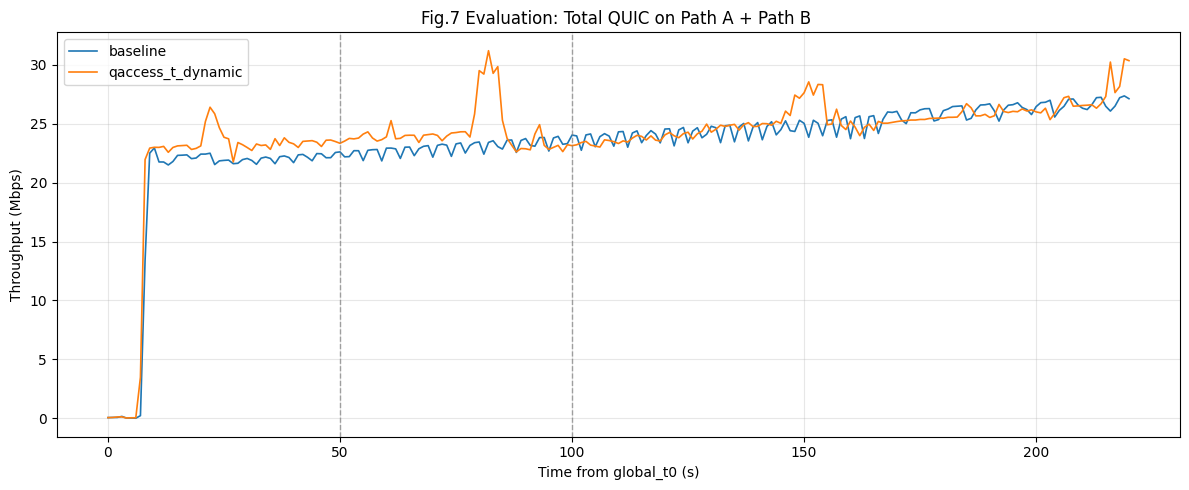

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_total_quic_throughput.png


In [23]:
# 6a. PRIMARY: Total QUIC/UDP wire throughput (both paths)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_baseline["second"], df_baseline["total_quic_mbps"], label="baseline", linewidth=1.2)
ax.plot(df_dynamic["second"], df_dynamic["total_quic_mbps"], label="qaccess_t_dynamic", linewidth=1.2)
for t in (50, 100):
    ax.axvline(t, linestyle="--", linewidth=1, color="gray", alpha=0.7)
ax.set_xlabel("Time from global_t0 (s)")
ax.set_ylabel("Throughput (Mbps)")
ax.set_title("Fig.7 Evaluation: Total QUIC on Path A + Path B ")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_TOTAL, dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_TOTAL)


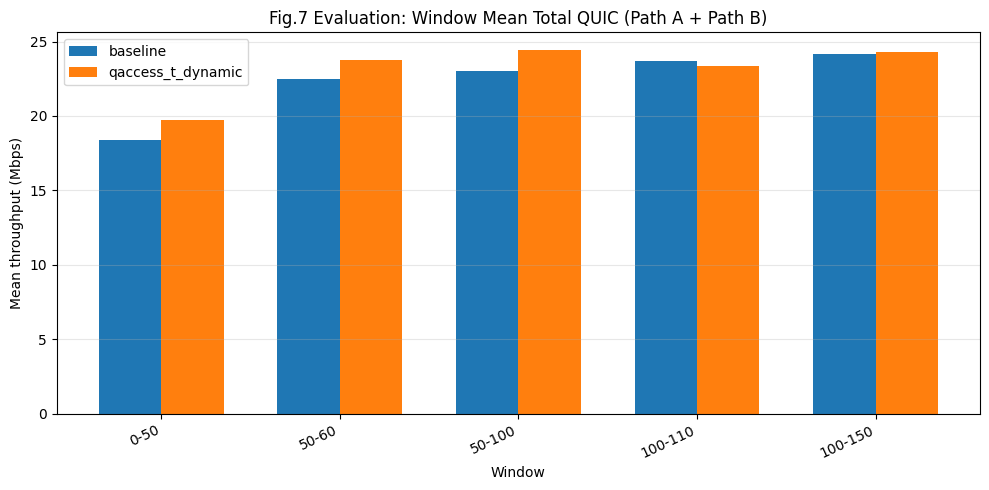

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_window_total_quic_throughput.png


In [24]:
# 6b. Window mean — total UDP (Path A + Path B)
plot_df = df_window_summary[df_window_summary["window"] != "full"].reset_index(drop=True)
x = range(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width / 2 for i in x], plot_df["baseline_total_mbps"], width=width, label="baseline")
ax.bar([i + width / 2 for i in x], plot_df["qaccess_t_dynamic_total_mbps"], width=width, label="qaccess_t_dynamic")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["window"].tolist(), rotation=25, ha="right")
ax.set_xlabel("Window")
ax.set_ylabel("Mean throughput (Mbps)")
ax.set_title("Fig.7 Evaluation: Window Mean Total QUIC (Path A + Path B)")
ax.legend(loc="best")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_WINDOW, dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_WINDOW)


## 7. Diagnostic plots (optional)


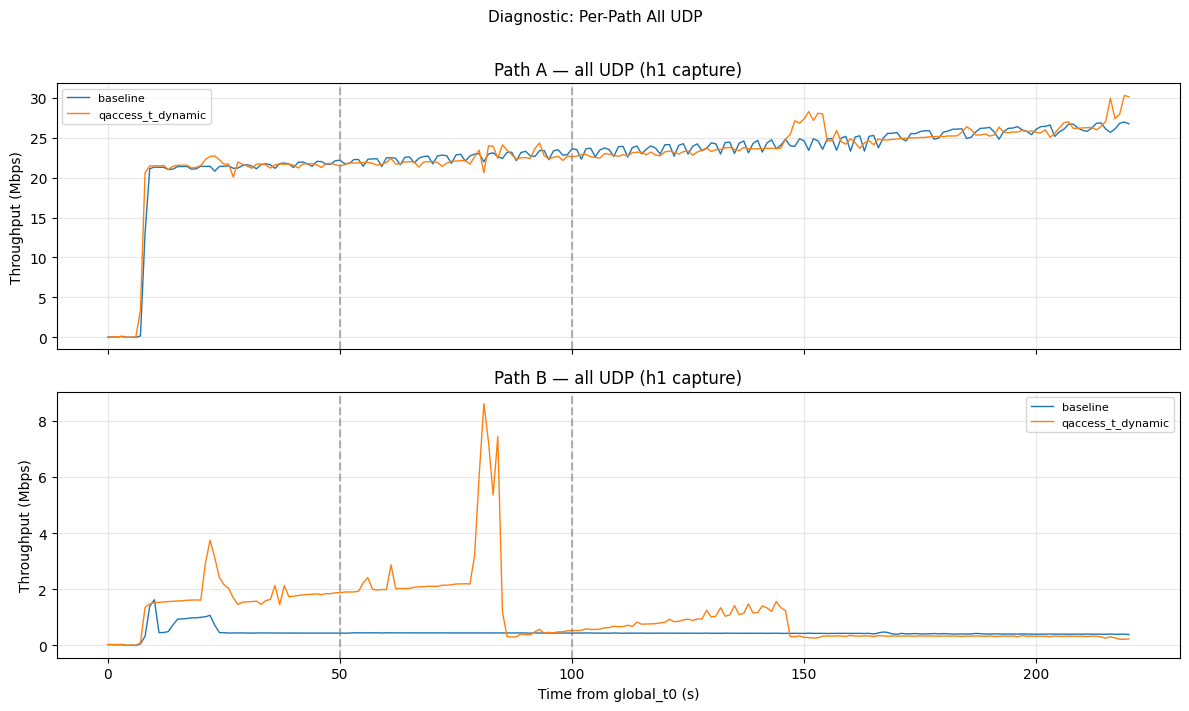

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_per_path_quic_throughput_diagnostic.png


In [ ]:
# 7a. Per-path all UDP (same metric as primary, split by interface)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, title in [
    (axes[0], "pathA_quic_mbps", "Path A — all UDP (h1 capture)"),
    (axes[1], "pathB_quic_mbps", "Path B — all UDP (h1 capture)"),
]:
    ax.plot(df_baseline["second"], df_baseline[col], label="baseline", linewidth=1.0)
    ax.plot(df_dynamic["second"], df_dynamic[col], label="qaccess_t_dynamic", linewidth=1.0)
    for t in (50, 100):
        ax.axvline(t, linestyle="--", color="gray", alpha=0.6)
    ax.set_ylabel("Throughput (Mbps)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel("Time from global_t0 (s)")
fig.suptitle("Diagnostic: Per-Path All QUIC", y=1.01, fontsize=11)
fig.tight_layout()
fig.savefig(FIG_PATHS_DIAG, dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_PATHS_DIAG)


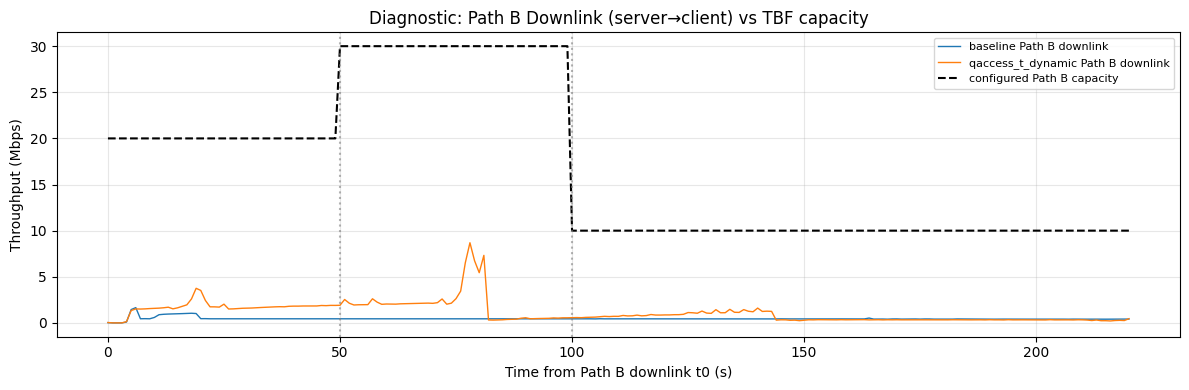

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_pathB_downlink_diagnostic.png


In [21]:
# 7b. Path B downlink only vs configured TBF capacity (diagnostic)
def pathB_downlink_series(run_dir: Path) -> pd.Series:
    _, pcap_b = find_pcaps(run_dir)
    df_b = read_pcap_rows(pcap_b, PATH_B_DOWNLINK_FILTER)
    if df_b.empty:
        return pd.Series(dtype="float64")
    t0 = float(df_b["epoch"].min())
    last_s = int(min(SECOND_MAX, math.floor(df_b["epoch"].max() - t0)))
    return aggregate_mbps(df_b, t0, last_s)


pb_base = pathB_downlink_series(RUNS["baseline"])
pb_dyn = pathB_downlink_series(RUNS["qaccess_t_dynamic"])
last_dn = int(max(len(pb_base), len(pb_dyn)) - 1)
seconds_dn = range(0, last_dn + 1)
cap = [configured_path_b_capacity_mbps(s) for s in seconds_dn]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(seconds_dn, pb_base.values, label="baseline Path B downlink", linewidth=1.0)
ax.plot(seconds_dn, pb_dyn.values, label="qaccess_t_dynamic Path B downlink", linewidth=1.0)
ax.plot(seconds_dn, cap, label="configured Path B capacity", linestyle="--", color="black")
for t in (50, 100):
    ax.axvline(t, linestyle=":", color="gray", alpha=0.6)
ax.set_xlabel("Time from Path B downlink t0 (s)")
ax.set_ylabel("Throughput (Mbps)")
ax.set_title("Diagnostic: Path B Downlink (server→client) vs TBF capacity")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_PATHB_DIAG, dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_PATHB_DIAG)


## 8. Summary

In [22]:
logged_baseline = read_input_path_from_logs(RUNS["baseline"])
logged_dynamic = read_input_path_from_logs(RUNS["qaccess_t_dynamic"])

print("=" * 60)
print("Fig.7-style capacity-change evaluation — summary")
print("=" * 60)
print("Session:", SESSION.resolve())
print("Compares: baseline vs qaccess_t_dynamic only (no qaccess_t_static)")
print("Scenario: fig7 (Path A 20 Mbps static; Path B 20 Mbps static + TBF 20→30→10 on h2-eth1)")
print()
print("Primary metric: all UDP on Path A + Path B captures (bidirectional), Mbps = sum of both paths.")
print("Input FLV (baseline logs):", logged_baseline or "(not in logs)")
print("Input FLV (dynamic logs):", logged_dynamic or "(not in logs)")
print("mp_topo default if --input-flv omitted:", DEFAULT_INPUT_FLV)
print()
print("Output CSV / figures under:", OUT_DIR.resolve())
for p in (FIG_TOTAL, FIG_WINDOW, CSV_WINDOW_SUMMARY):
    print(" ", p)
print()
print("Diagnostic only:", FIG_PATHS_DIAG, FIG_PATHB_DIAG)
print()
display(df_window_summary)


Fig.7-style capacity-change evaluation — summary
Session: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354
Compares: baseline vs qaccess_t_dynamic only (no qaccess_t_static)
Scenario: fig7 (Path A 20 Mbps static; Path B 20 Mbps static + TBF 20→30→10 on h2-eth1)

Primary metric: all UDP on Path A + Path B captures (bidirectional), Mbps = sum of both paths.
Input FLV (baseline logs): (not in logs)
Input FLV (dynamic logs): (not in logs)
mp_topo default if --input-flv omitted: /Users/jememalum/Videos/push_input.flv

Output CSV / figures under: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv
  /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_total_quic_throughput.png
  /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_fig7_dynamic_20260602_201354/compare_csv/fig7_dynamic_window

,window,baseline_total_mbps,qaccess_t_dynamic_total_mbps,improvement_pct,baseline_pathA_mbps,qaccess_t_dynamic_pathA_mbps,baseline_pathB_mbps,qaccess_t_dynamic_pathB_mbps
0,0-50,18.390,19.728,7.27,17.873,18.196,0.517,1.532
1,50-60,22.456,23.758,5.80,22.009,21.746,0.447,2.013
2,50-100,22.989,24.400,6.13,22.544,22.280,0.446,2.120
3,100-110,23.715,23.331,-1.62,23.273,22.744,0.442,0.587
4,100-150,24.185,24.317,0.55,23.748,23.423,0.437,0.895
5,full,23.173,23.890,3.09,22.723,22.758,0.450,1.132
